# PHYS 295 Lab 4 (Part B) Code
I will use this code to get the linear graph needed for the Lab 4b assignment.

In [129]:
from scipy.optimize import curve_fit
import scipy.stats
from scipy.special import factorial

from matplotlib import pyplot as plt
import numpy as np 
import pandas as pd
import csv

#cesium_s1 = [1734, 17026, 17074, 16986]
#cesium_s2 = [2135, 20308, 20294, 20209]
#cesium_s1s2 = [0, 32569, 32580, 32722]
cesium_s1 = [17026, 17074, 16986]
cesium_s2 = [20308, 20294, 20209]
cesium_s1s2 = [32569, 32580, 32722]
table = {"Distance (cm)": [6.9, 6.9, 6.9] ,
         "Time (s)": [100, 100, 100],
         "CS 1": cesium_s1,
         "Source 1 Error": [round(np.sqrt(x), 2) for x in cesium_s1],
         "CS 2": cesium_s2,
         "Source 2 Error": [round(np.sqrt(x), 2) for x in cesium_s2],
         "CS 1+2": cesium_s1s2,
         "Source 1+2 Error": [round(np.sqrt(x), 2) for x in cesium_s1s2]}

show_table = pd.DataFrame(data=table)
show_table

,Distance (cm),Time (s),CS 1,Source 1 Error,CS 2,Source 2 Error,CS 1+2,Source 1+2 Error
0,6.9,100,17026,130.48,20308,142.51,32569,180.47
1,6.9,100,17074,130.67,20294,142.46,32580,180.50
2,6.9,100,16986,130.33,20209,142.16,32722,180.89


## Calculation of the Dead Time of the G-M Tube

In [146]:
c1 = np.mean(cesium_s1)/100
c2 = np.mean(cesium_s2)/100
c12 = np.mean(cesium_s1s2)/100
dead_time = ((c1+c2)-c12)/(2*c1*c2)
print(round(c1, 2), round(c2, 2), round(c12, 2))
print(f"The dead time of the G-M tube is {round(dead_time, 9)} seconds")

170.29 202.7 326.24
The dead time of the G-M tube is 0.000677238 seconds


## Histogram of the Data

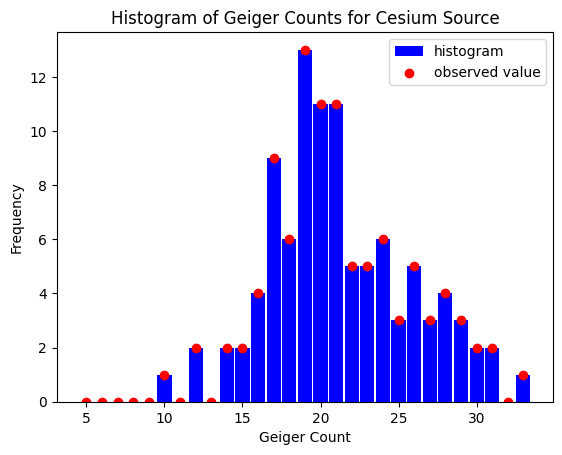

In [131]:
def load_data(filename):
    mylist = []
    with open(filename) as numbers:
        numbers_data = csv.reader(numbers, delimiter=",")
        next(numbers_data) #skip the header
        for row in numbers_data:
            mylist.append(row)
        return mylist

def count(datalist):
    count_column = []
    for i in range(len(datalist)):
        count_column.append(int(datalist[i][2]))
    return count_column

plt.figure()
hist = load_data("PHYS 295 Lab 4b (Ionizing Radiation).csv")
geiger = count(hist)
data = plt.hist(geiger, bins=np.arange(5, 35, 1).tolist(), align='left', label="histogram", histtype='bar', rwidth=0.9, color='blue') 
ban = data[1][0:29]

plt.scatter(ban, data[0], label="observed value", color='red') 
plt.title("Histogram of Geiger Counts for Cesium Source") 
plt.xlabel('Geiger Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Histogram of the Data (with a Poisson Distribution Line of Best Fit)

[ 1.  0.  2.  0.  2.  2.  4.  9.  6. 13. 11. 11.  5.  5.  6.  3.  5.  3.
  4.  3.  2.  2.  0.  1.]
[ 9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5
 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5 33.5]


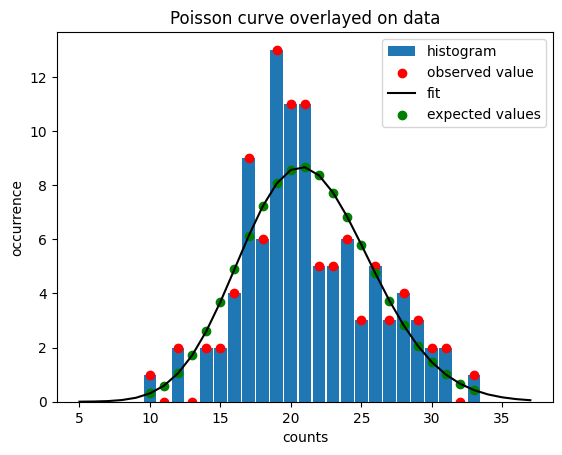

In [132]:
plt.figure()

def P(N,Nbar):
    lnprob=N*np.log(Nbar) - Nbar - scipy.special.gammaln(N+1)
    return np.exp(lnprob)

#Read raw trails from excel sheet (trail number vs observed counts)
#filelow=pd.read_csv(r'./Radon-lowcount(77) - Sheet1 (3).csv')
data=geiger
#Check if data is loaded correctly
#print(data)

min_count = min(data)
max_count = max(data)
#print(min_count, max_count)

#Create approopriate boundaries
bin_boundaries = []
for i in range (0,(max_count-min_count+1)+1):
    bin_boundaries.append(i+(min(data)-0.5))

## Plot histogram of the distribution
hist_data = plt.hist(data,bin_boundaries,label='histogram',rwidth=0.90)

# Extract counts and occurrence from the histogram
counts1=[]
for i in range(min_count,max_count+1):
    counts1.append(i)
counts = np.array(counts1)
occurrence = hist_data[0]
print(occurrence)
print(hist_data[1])

# Mean calculation
m=0
for i in range(0, len(counts)):
    m= m+ counts[i]*occurrence[i]
    
#Mean of the distribution
mean= m/sum(occurrence)
Mean_counts= mean 
#print("Mean of distribution is :" , Mean_counts)

#Scatter plot of the distribution, i.e, heights of bars on histogram (**should be avilable in the input file**) vs counts
plt.scatter(counts, occurrence,label='observed value',color='red') 

# Creating a x_values for plotting a smooth fit
l=list(range(max(min(counts)-5,0),max(counts)+5)) #(N can not be less than zero for P(N))
l1=np.array(l,dtype='double') # Changing data type to accommodate high exponentials
#print("list of x values for plotting are= ",l1)

#Genrate data poitns to make smooth curve
y_for_fit = P(l1,float(mean))
plt.plot(l1,y_for_fit*np.sum(occurrence),'k',label='fit')
#----------------------------------------------------

#Scatter plot of expected points on the curve
expexted_y_values = P(counts,float(mean))*np.sum(occurrence)
plt.scatter(counts,expexted_y_values,color='green',label='expected values')
#-------------------------------------------------------

## Chi_square calculation
chi_square=0
for i in range(0,len(counts)):
    chi_square = chi_square + ((occurrence[i]-expexted_y_values[i])**2)/(expexted_y_values[i])
#-------------------------------------------------------
        
# Plot graph        
plt.xlabel("counts")
plt.ylabel("occurrence")
plt.title("Poisson curve overlayed on data")
plt.legend()
plt.show()    

In [133]:
value = np.mean(geiger)
log_value = np.sqrt(value)
print(f"The mean of the graph is {value}")
print(f"The standard deviation of the graph is {log_value}")

The mean of the graph is 21.24
The standard deviation of the graph is 4.608687448721165


## Background Counting Rate

In [134]:
bg_count_rate = 100/80.79
print(f"The background counting rate for our system was {round(bg_count_rate, 2)} per second")
print(f"The uncertainty of the background counting rate was {1/np.sqrt(100)}")

The background counting rate for our system was 1.24 per second
The uncertainty of the background counting rate was 0.1


## Counting Rate

In [135]:
count_rate = 21.24/10
print(f"The background counting rate for our system was {round(count_rate, 2)} per second")
print(f"The uncertainty of the background counting rate was {1/np.sqrt(value)}")

The background counting rate for our system was 2.12 per second
The uncertainty of the background counting rate was 0.2169815183013731


In [136]:
print(f"Accounting for the background counting rate, the real counting rate of the system is {round(count_rate - bg_count_rate, 2)} per second")

Accounting for the background counting rate, the real counting rate of the system is 0.89 per second
